In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from joblib.testing import param

df = pd.read_csv('broadband.csv')
df.head()

,CUST_ID,GENDER,AGE,TENURE,CHANNEL,AUTOPAY,ARPB_3M,CALL_PARTY_CNT,DAY_MOU,AFTERNOON_MOU,NIGHT_MOU,AVG_CALL_LENGTH,BROADBAND
0,63,1,34,27,2,0,203,0,0.0,0.0,0.0,3.04,1
1,64,0,62,58,1,0,360,0,0.0,1910.0,0.0,3.30,1
2,65,1,39,55,3,0,304,0,437.2,200.3,0.0,4.92,0
3,66,1,39,55,3,0,304,0,437.2,182.8,0.0,4.92,0
4,67,1,39,55,3,0,304,0,437.2,214.5,0.0,4.92,0


### 表 宽带订阅用户数据集字段含义

| 字段名称 | 中文含义 | 字段名称 | 中文含义 |
|----------|----------|----------|----------|
| CUST_ID | 客户ID | CALL_PARTY_CNT | 通话次数 |
| GENDER | 性别 | DAY_MOU | 白天通话时长 |
| AGE | 年龄 | AFTERNOON_MOU | 下午通话时长 |
| TENURE | 服务期限 | NIGHT_MOU | 晚上通话时长 |
| CHANNEL | 渠道 | AVG_CALL_LENGTH | 平均通话时长 |
| AUTOPAY | 自动付款 | BROADBAND | 宽带（因变量） |
| ARPB_3M | 过去3个月平均每用户收入 | | |

---


In [3]:
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# 拆分数据集
y = df['BROADBAND']
X = df.drop(columns = ['CUST_ID','BROADBAND'])
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

# 定义并拟合bagging分类器，默认决策树是基模型
bgc = BaggingClassifier(n_estimators=10,max_samples=0.8)
bgc.fit(X_train,y_train)

y_pred = bgc.predict(X_test)#预测测试集
accuracy = accuracy_score(y_test,y_pred)# 计算准确率
print('Bagging准确率：',accuracy)

Bagging准确率： 0.8776119402985074


###  BaggingClassifier的常用参数

| 参数名 | 参数含义 |
|:--- |:--- |
| **base_estimator** | 基分类器 |
| **n_estimators** | 基分类器的数量 |
| **max_samples** | 每个基分类器使用的样本数（0～1） |
| **max_features** | 每个基分类器使用的特征数（0～1） |
| **bootstrap** | 是否进行自助采样 |
| **bootstrap_features** | 是否进行特征自助采样 |
| **random_state** | 随机数种子 |


In [7]:
#基模型为逻辑回归
from sklearn.linear_model import LogisticRegression
base_model = LogisticRegression()
lg_bgc = BaggingClassifier(estimator=base_model,
                           n_estimators = 5,
                           max_samples = 0.8,
                           max_features=0.8)
#max_samples=0.8，随机抽取训练集中80%的样本来训练每个基模型
# max_features=0.8，从随机抽取的样本中，随机保留80%的特征来训练基模型
lg_bgc.fit(X_train,y_train)

y_pred = lg_bgc.predict(X_test)#预测测试集
accuracy = accuracy_score(y_test,y_pred)#计算准确率
print('基模型为逻辑回归时,Bagging准确率：',accuracy)

基模型为逻辑回归时,Bagging准确率： 0.8417910447761194


C:\Users\24677\PycharmProjects\Data_Analysis_Project\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\24677\PycharmProjects\Data_Analysis_Project\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https

决策树作为基模型时bagging准确率更高，，所以选择决策树作为基模型

用交叉验证实现参数的最佳取值

In [8]:
from sklearn.model_selection import GridSearchCV

# 定义baggingClassifier模型
model = BaggingClassifier()

# 定义参数网络
param_grid = {
    'max_samples': [0.6,0.7,0.8,0.9],
    'max_features': [0.6,0.7,0.8,0.9]
}

# 使用网格搜索和交叉验证寻找最佳参数
grid = GridSearchCV(model, param_grid = param_grid,cv = 5)
grid.fit(X_train,y_train)

# 输出最佳参数和得分
print('Best params:',grid.best_params_)
print('Best score:',grid.best_score_)

Best params: {'max_features': 0.7, 'max_samples': 0.9}
Best score: 0.8908602150537634


使用随机森林建模：

In [11]:
param_grid = {
    'criterion':['gini','entropy'],
    'max_depth':[None],
    'n_estimators':[10,15,20,25,30],
    'class_weight':[{0:1,1:2},{0:1,1:3}]
}

#构建随机森林，这里直接使用网格搜索
import sklearn.ensemble as ensemble #ensemble learning:集成学习
rfc = ensemble.RandomForestClassifier()
rfc_cv = GridSearchCV(estimator=rfc,param_grid=param_grid,scoring = 'roc_auc',cv=4)
rfc_cv.fit(X_train,y_train)

#模型评估
from sklearn.metrics import classification_report
y_pred = rfc_cv.predict(X_test)
report = classification_report(y_test,y_pred)
print('评估报告：\n',report)


评估报告：
               precision    recall  f1-score   support

           0       0.87      0.99      0.93       268
           1       0.90      0.42      0.57        67

    accuracy                           0.87       335
   macro avg       0.89      0.70      0.75       335
weighted avg       0.88      0.87      0.86       335



### 业务视角下的随机森林模型评估报告分析

#### 1. 整体业务表现：准确率不错，但类别不均衡问题突出
- **整体准确率 87%**：模型在测试集上整体预测正确的比例较高，说明对大部分用户的宽带订阅/离网行为有较好的判断能力，具备一定的业务落地价值。
- **样本分布不均**：测试集中非离网用户（0类）有268人，离网用户（1类）仅67人，属于**典型的不平衡数据集**，这会导致模型更偏向预测多数类（非离网），而对少数类（离网）的识别能力较弱。

---

#### 2. 核心业务指标拆解（离网用户是业务重点）
| 指标 | 非离网用户(0) | 离网用户(1) | 业务解读 |
|------|----------------|--------------|----------|
| **精确率(Precision)** | 0.87 | 0.90 | 预测为离网的用户中，90%确实是离网用户，**误杀率低**，适合精准营销触达，避免打扰非离网用户。 |
| **召回率(Recall)** | 0.99 | 0.42 | 真实离网用户中，仅42%被模型识别出来，**漏判率高**，超过一半的高价值离网用户被遗漏。 |
| **F1分数** | 0.93 | 0.57 | 离网用户的F1分数仅0.57，说明模型在离网用户识别上的综合表现较差，是业务短板。 |

---

#### 3. 业务痛点与风险
1.  **离网用户识别不足，营收流失风险高**
    召回率仅0.42意味着：每100个真实要离网的用户，有58个没被模型识别出来，运营商无法及时采取挽留措施，直接导致**宽带用户流失、营收损失**。
2.  **非离网用户预测极准，资源浪费风险低**
    非离网用户召回率0.99，说明模型几乎不会把正常用户误判为离网，避免了对稳定用户的过度营销，**营销资源投放更精准**。
3.  **类别不均衡是根本原因**
    离网用户样本过少，模型学习不到足够的离网特征，导致“宁愿漏判，也不错判”的偏向，这是不平衡数据集的典型问题。

---

#### 4. 业务优化建议
##### （1）优先解决样本不均衡问题
- **过采样/欠采样**：对离网用户做SMOTE过采样，或对非离网用户做欠采样，平衡两类样本数量；
- **调整class_weight**：在随机森林中进一步加大离网用户（1类）的权重（比如 `{0:1, 1:4}` 或更高），让模型更关注离网用户的识别。

##### （2）优化模型评估与决策阈值
- 业务更关注**召回率**（不想漏掉任何一个离网用户），可以：
  - 调整分类阈值（比如降低预测为1类的概率阈值），牺牲部分精确率换取更高召回率；
  - 用 `roc_auc_score` 替代准确率作为主要评估指标，更适合不平衡数据。

##### （3）特征工程与业务洞察
- 分析模型识别出的**离网用户关键特征**（比如通话时长骤降、服务期限短、未开通自动付款等），针对性制定挽留策略：
  - 对高风险离网用户推出**套餐优惠、增值服务赠送**；
  - 优化服务体验，缩短服务期限短的用户的流失周期。

##### （4）业务落地场景
- **精准挽留**：将模型预测为高风险的离网用户（精确率0.90）交给客服团队，进行一对一挽留；
- **资源倾斜**：把营销预算优先投入到高召回率的离网用户群体，最大化挽回营收。

---

#### 5. 总结
- 模型**整体准确率高**，对非离网用户识别优秀，适合稳定现有用户；
- 但**离网用户召回率过低**是核心业务短板，会导致大量用户流失无法被及时干预；
- 下一步重点是**解决样本不均衡问题**+**优化模型对离网用户的识别能力**，才能让模型真正为业务创造价值。

---


In [12]:
rfc_cv.best_params_

{'class_weight': {0: 1, 1: 2},
 'criterion': 'gini',
 'max_depth': None,
 'n_estimators': 25}

可视化：

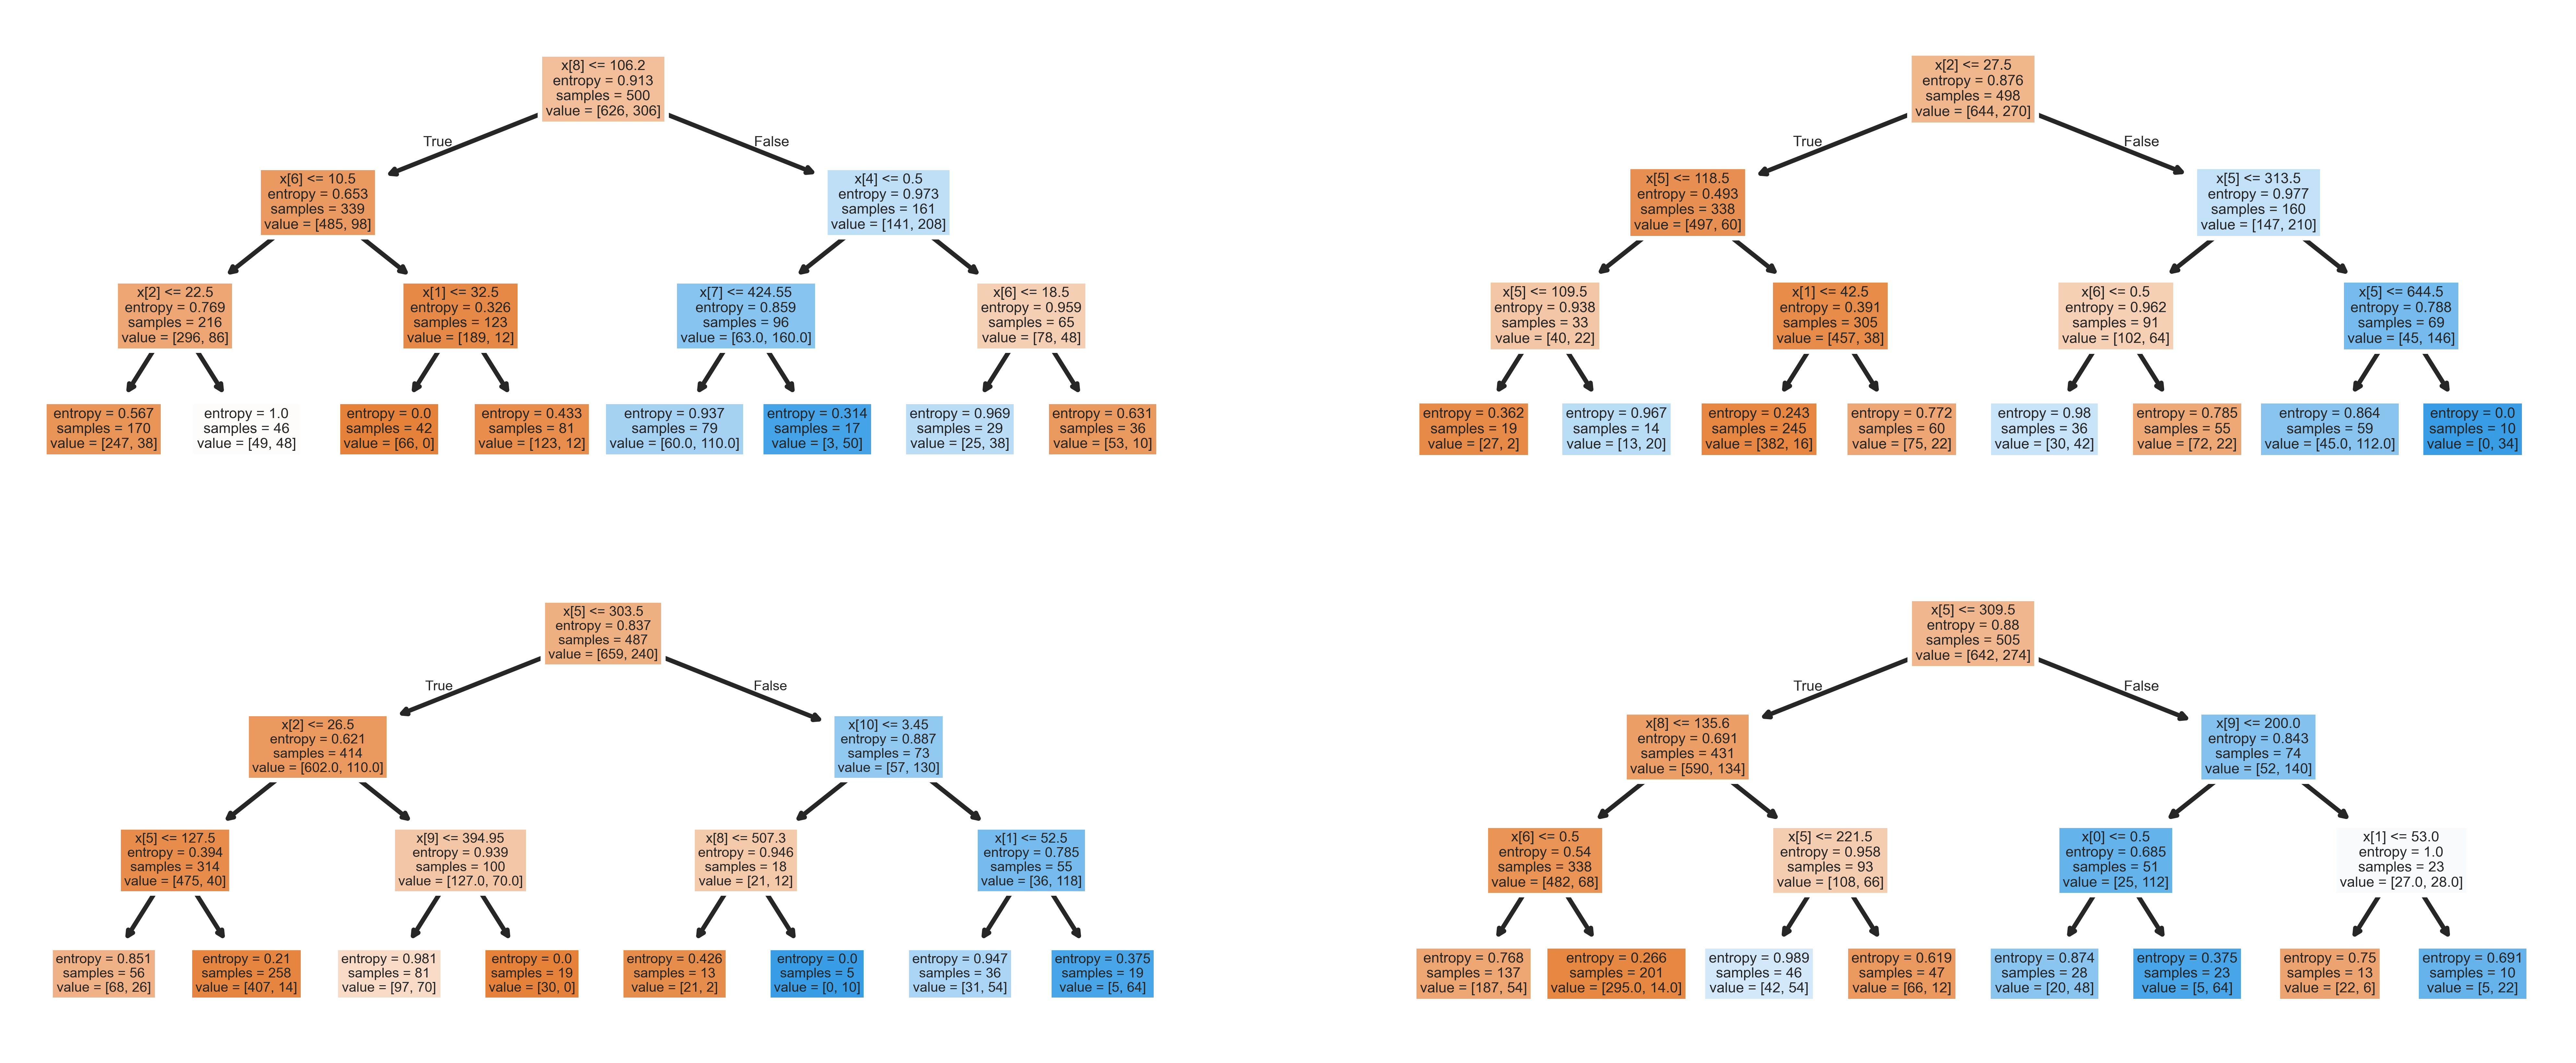

In [15]:
param_grid = {
    'criterion':['gini','entropy'],
    'max_depth':[None],
    'n_estimators':[10,15,20,25,30],
    'class_weight':[{0:1,1:2},{0:1,1:3}]
}

# 按照最佳参数组合重新训练一个随机森林模型为了方便展示，每棵树的最大深度设置为三
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
rfc = ensemble.RandomForestClassifier(n_estimators=30,
                                      criterion='entropy',
                                      max_depth=3,
                                      class_weight={0:1,1:2})
rfc.fit(X_train,y_train)
fig,axes = plt.subplots(nrows=2,ncols=2,figsize = (10,4),dpi = 1000)
for i in range(4):
    plot_tree(rfc.estimators_[i],filled = True,ax = axes.flatten()[i])

### 随机森林决策树可视化业务解读
这张图展示了随机森林中4棵决策树的结构，每棵树都在学习“用户是否会宽带离网”的决策逻辑，可以从**业务特征**和**离网判断**两个角度来分析：

---

#### 1. 核心特征识别（x 对应你的特征列）
从节点分裂的高频特征可以看出，模型认为以下特征对判断离网最关键：
- **`x[2]`（AGE，年龄）**：多次出现在根节点/上层节点（如 `x[2] <= 22.5`、`x[2] <= 26.5`），说明**年轻用户**是离网高风险群体。
- **`x[5]`（DAY_MOU，白天通话时长）**：频繁作为分裂特征（如 `x[5] <= 118.5`、`x[5] <= 303.5`），**白天通话时长越低**，用户越可能离网（活跃度下降）。
- **`x[8]`（ARPB_3M，过去3个月平均每用户收入）**：多次出现（如 `x[8] <= 106.2`），**ARPU值较低**的用户更容易流失，对价格更敏感。
- **`x[6]`（TENURE，服务期限）**：如 `x[6] <= 10.5`，**在网时间短**的用户留存意愿弱，是离网高发群体。

---

#### 2. 离网用户的典型决策路径
以左上角第一棵树为例：
1.  **根节点**：`x[8] <= 106.2`（ARPU ≤ 106.2）→ 进入左子树（高风险群体）
2.  **第二层**：`x[6] <= 10.5`（在网时长 ≤ 10.5个月）→ 进入左子树（更年轻的新用户）
3.  **第三层**：`x[2] <= 22.5`（年龄 ≤ 22.5岁）→ 最终叶子节点：`value = [247, 38]`
    - 含义：该组用户中，**38人是离网用户**，247人是留存用户，是模型识别的高离网风险组。

---

#### 3. 业务洞察与运营建议
 **高离网风险用户画像**：
- 年轻（年龄 ≤ 22.5/26.5岁）
- 在网时间短（服务期限 ≤ 10.5个月）
- 白天通话时长少（活跃度低）
- ARPU值低（对价格敏感，付费意愿弱）

 **针对性运营策略**：
1.  **新用户留存**：对在网时间短的年轻用户，推出**首年优惠套餐**或**校园专属流量包**，提升初期粘性。
2.  **低活跃唤醒**：对白天通话时长少的用户，推送**语音通话优惠**或**亲情号绑定活动**，提升使用频率。
3.  **低ARPU挽留**：对ARPU值低的用户，提供**性价比更高的套餐升级方案**，避免因价格原因转网。

---

#### 4. 模型可解释性价值
- 可以清晰看到**哪些特征在驱动离网预测**，而不是只得到一个分数。
- 不同树的分裂特征略有差异，体现了集成学习的“多样性”，最终投票结果更稳定。

---

###  总结
这张图直观揭示了：**年轻、新入网、低活跃、低ARPU**的用户是宽带离网的核心风险群体，模型的决策逻辑和业务直觉高度一致，具备很强的落地指导价值。
